# Case 1: Arm Making the Body "Unnaturally Bigger"

## FIFA Rule (Law 12 – IFAB)
A handball offence occurs if the ball touches the hand/arm and **"the hand or arm has made the body unnaturally bigger"**. This means the arm position is not natural for the player's movement.

## Why This Is Debatable
- The rule does not clearly define what "unnaturally bigger" means.
- Players move their arms naturally when running, jumping, or turning.
- Different referees may interpret the same arm position differently.
- Camera angles can alter perception.

## How AI Can Help
We use **two AI models** together:
1. **Pose estimation model** (YOLOv8-pose) — detects body keypoints (shoulders, elbows, wrists, hips) and measures the arm-torso angle.
2. **Ball detection model** (YOLOv8x / custom trained) — detects the football in each frame.

### Decision Logic
A **handball foul** is flagged when **both** conditions are met:
- The arm is in an **unnatural position** (arm-torso angle > 70° = HIGH risk).
- The ball is **close to the arm** (distance between ball center and wrist/elbow is below a threshold).

Neither condition alone is enough — a raised arm without ball contact is not a foul, and a ball near a tucked arm is not a foul either. This gives the referee an **objective, two-factor decision** instead of a subjective opinion.

## Step 1 – Import Libraries
We import:
- **cv2** (OpenCV) for video/image processing
- **numpy** for numerical operations (angles, distances)
- **YOLO** from ultralytics for pose estimation and ball detection models
- **matplotlib** for displaying frames inline
- **math** for trigonometric calculations

In [ ]:
# installing ultralytics package
!pip install ultralytics

In [9]:
import cv2
import numpy as np
import math
from ultralytics import YOLO
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Display images inline in the notebook
%matplotlib inline

## Step 2 – Configuration

We define:
- **VIDEO_PATH**: Path to the input football video.
- **OUTPUT_PATH**: Where the annotated output video will be saved.
- **MODEL_POSE**: The YOLOv8-pose model that detects body keypoints.
- **MODEL_BALL**: The YOLOv8 model used for detecting the football.
- **BALL_DISTANCE_THRESHOLD**: Maximum pixel distance between the ball center and an arm keypoint to consider it "contact" (proximity).

### YOLOv8 Pose Keypoint Indices (COCO format)
The pose model detects 17 keypoints per person. The ones relevant to handball detection are:

| Index | Keypoint |
|-------|----------|
| 5 | Left Shoulder |
| 6 | Right Shoulder |
| 7 | Left Elbow |
| 8 | Right Elbow |
| 9 | Left Wrist |
| 10 | Right Wrist |
| 11 | Left Hip |
| 12 | Right Hip |

We use these to calculate the angle between the upper arm and the torso, and measure the distance from arm keypoints to the ball.

In [10]:
# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------
VIDEO_PATH = "../input.mp4"                        # Input football video
OUTPUT_PATH = "../output/case1_arm_unnaturally_bigger.mp4"  # Output annotated video
MODEL_POSE = "../yolov8n-pose.pt"                  # YOLOv8 Pose estimation model
MODEL_BALL = "../yolov8x.pt"                       # YOLOv8 Ball detection model (use "../models/best5.pt" for custom trained)

# Keypoint indices (COCO format used by YOLOv8-pose)
LEFT_SHOULDER = 5
RIGHT_SHOULDER = 6
LEFT_ELBOW = 7
RIGHT_ELBOW = 8
LEFT_WRIST = 9
RIGHT_WRIST = 10
LEFT_HIP = 11
RIGHT_HIP = 12

# Risk thresholds (in degrees) for the arm-torso angle
# These define how far the arm is from the body
ANGLE_LOW = 30     # Below this = Low risk (arm close to body)
ANGLE_HIGH = 70    # Above this = High risk (arm far from body, "unnaturally bigger")
# Between ANGLE_LOW and ANGLE_HIGH = Medium risk

# Ball proximity threshold (in pixels)
# If the ball center is within this distance of an arm keypoint, we consider it "contact"
BALL_DISTANCE_THRESHOLD = 150

# COCO class ID for "sports ball" (used when MODEL_BALL is a general COCO model like yolov8x.pt)
# If using a custom-trained model where ball = class 0, set this to [0]
BALL_CLASS_ID = [32]   # 32 = sports ball in COCO

print("Configuration loaded.")

Configuration loaded.


## Step 3 – Helper Functions

### How the Angle Calculation Works

To determine if an arm is making the body "unnaturally bigger", we measure the **angle between the upper arm and the torso**:

1. **Torso vector**: From the shoulder down to the hip on the same side (e.g., left shoulder → left hip). This represents the body's midline.
2. **Arm vector**: From the shoulder to the elbow (e.g., left shoulder → left elbow). This represents the upper arm direction.
3. **Angle**: We use the dot product formula to calculate the angle between these two vectors.

$$\theta = \arccos\left(\frac{\vec{a} \cdot \vec{b}}{|\vec{a}| \cdot |\vec{b}|}\right)$$

Where $\vec{a}$ is the torso vector and $\vec{b}$ is the arm vector.

### How the Ball Proximity Works

We also calculate the **Euclidean distance** between the ball center and each arm keypoint (elbow, wrist):

$$d = \sqrt{(x_{ball} - x_{arm})^2 + (y_{ball} - y_{arm})^2}$$

If $d < \text{BALL\_DISTANCE\_THRESHOLD}$, the ball is considered close enough for potential contact.

### Final Handball Decision

| Arm Angle Risk | Ball Close to Arm? | Decision |
|---------------|-------------------|----------|
| LOW | Yes or No | **No Handball** — arm in natural position |
| MEDIUM | No | **No Handball** — no contact |
| MEDIUM | Yes | **Possible Handball** — needs review |
| HIGH | No | **No Handball** — no contact |
| HIGH | Yes | **Handball Detected** — arm unnaturally bigger + ball contact |

In [11]:
def calculate_angle(point_a, point_b, point_c):
    """
    Calculate the angle at point_a between vectors (point_a -> point_b) and (point_a -> point_c).
    
    In our case:
      - point_a = shoulder
      - point_b = hip (torso direction)
      - point_c = elbow (arm direction)
    
    Returns the angle in degrees.
    """
    # Create vectors from shoulder to hip, and shoulder to elbow
    vector_torso = np.array([point_b[0] - point_a[0], point_b[1] - point_a[1]])
    vector_arm   = np.array([point_c[0] - point_a[0], point_c[1] - point_a[1]])
    
    # Calculate magnitudes
    mag_torso = np.linalg.norm(vector_torso)
    mag_arm   = np.linalg.norm(vector_arm)
    
    # Avoid division by zero (keypoint not detected properly)
    if mag_torso == 0 or mag_arm == 0:
        return None
    
    # Dot product and angle
    dot_product = np.dot(vector_torso, vector_arm)
    cos_angle = np.clip(dot_product / (mag_torso * mag_arm), -1.0, 1.0)
    angle_deg = math.degrees(math.acos(cos_angle))
    
    return angle_deg


def classify_risk(angle):
    """
    Classify the arm position risk based on the arm-torso angle.
    
    Returns:
        - "LOW"    if angle < ANGLE_LOW  (arm close to body)
        - "MEDIUM" if ANGLE_LOW <= angle <= ANGLE_HIGH
        - "HIGH"   if angle > ANGLE_HIGH (arm far from body, "unnaturally bigger")
    """
    if angle is None:
        return "UNKNOWN"
    if angle < ANGLE_LOW:
        return "LOW"
    elif angle <= ANGLE_HIGH:
        return "MEDIUM"
    else:
        return "HIGH"


def get_risk_color(risk):
    """Return a BGR color based on risk level for visualization."""
    if risk == "LOW":
        return (0, 255, 0)      # Green
    elif risk == "MEDIUM":
        return (0, 165, 255)    # Orange
    elif risk == "HIGH":
        return (0, 0, 255)      # Red
    else:
        return (200, 200, 200)  # Grey for unknown


def is_keypoint_valid(kp):
    """Check if a keypoint was actually detected (not at origin 0,0)."""
    return kp[0] != 0 or kp[1] != 0


def get_ball_centers(ball_results):
    """
    Extract ball center points from the ball detection results.
    
    Returns a list of (cx, cy) tuples — one per detected ball.
    """
    centers = []
    if len(ball_results[0].boxes) > 0:
        for box in ball_results[0].boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2
            centers.append((cx, cy))
    return centers


def min_distance_to_ball(arm_keypoints, ball_centers):
    """
    Calculate the minimum Euclidean distance between any arm keypoint
    and any detected ball center.
    
    Args:
        arm_keypoints: list of (x, y) arrays — the elbow and wrist positions
        ball_centers:  list of (cx, cy) tuples — detected ball centers
    
    Returns:
        (min_dist, closest_arm_point, closest_ball_point) or (None, None, None) if no valid pair
    """
    min_dist = float('inf')
    closest_arm = None
    closest_ball = None
    
    for kp in arm_keypoints:
        if not is_keypoint_valid(kp):
            continue
        for bc in ball_centers:
            dist = math.sqrt((kp[0] - bc[0])**2 + (kp[1] - bc[1])**2)
            if dist < min_dist:
                min_dist = dist
                closest_arm = kp
                closest_ball = bc
    
    if min_dist == float('inf'):
        return None, None, None
    return min_dist, closest_arm, closest_ball


def make_handball_decision(arm_risk, ball_distance):
    """
    Combine arm angle risk and ball proximity into a final handball decision.
    
    Decision logic:
      - HIGH risk arm + ball close  → "HANDBALL DETECTED"
      - MEDIUM risk arm + ball close → "POSSIBLE HANDBALL"
      - Anything else               → "NO HANDBALL"
    
    Returns: (decision_string, decision_color_bgr)
    """
    if ball_distance is None:
        return "NO HANDBALL", (0, 255, 0)
    
    ball_close = ball_distance < BALL_DISTANCE_THRESHOLD
    
    if arm_risk == "HIGH" and ball_close:
        return "HANDBALL DETECTED", (0, 0, 255)         # Red
    elif arm_risk == "MEDIUM" and ball_close:
        return "POSSIBLE HANDBALL", (0, 165, 255)        # Orange
    else:
        return "NO HANDBALL", (0, 255, 0)                # Green


print("Helper functions defined.")

Helper functions defined.


## Step 4 – Load the Models

We load **two models**:
1. **YOLOv8n-pose** — a lightweight pose estimation model that detects 17 body keypoints per person. Used to measure arm angles.
2. **YOLOv8x** (or a custom-trained model) — an object detection model used to detect the football in each frame. Used to measure ball proximity to the arm.

In [12]:
# Load the YOLOv8 Pose Estimation model
print("Loading pose estimation model...")
pose_model = YOLO(MODEL_POSE)
print("Pose model loaded successfully!")

# Load the YOLOv8 Ball Detection model
print("Loading ball detection model...")
ball_model = YOLO(MODEL_BALL)
print("Ball model loaded successfully!")

Loading pose estimation model...
Pose model loaded successfully!
Loading ball detection model...


Ball model loaded successfully!


## Step 5 – Test on a Single Frame

Before processing the entire video, let's test on a single frame. This lets us:
1. Verify **both models** (pose + ball) are working correctly.
2. Visualize the arm angles **and** the ball detection together.
3. See the **combined handball decision** (arm risk + ball proximity) on a real frame.

The ball is drawn with an **orange bounding box**. A dashed line is drawn from the ball to the nearest arm keypoint, with the distance in pixels displayed.

Detected 1 ball(s) in the frame.

Detected 1 person(s) in the frame.

--- Person 1 ---
  Left arm angle:  14.4° → Risk: LOW | Ball dist: 197px → NO HANDBALL
  Right arm angle: 46.2° → Risk: MEDIUM | Ball dist: 185px → NO HANDBALL



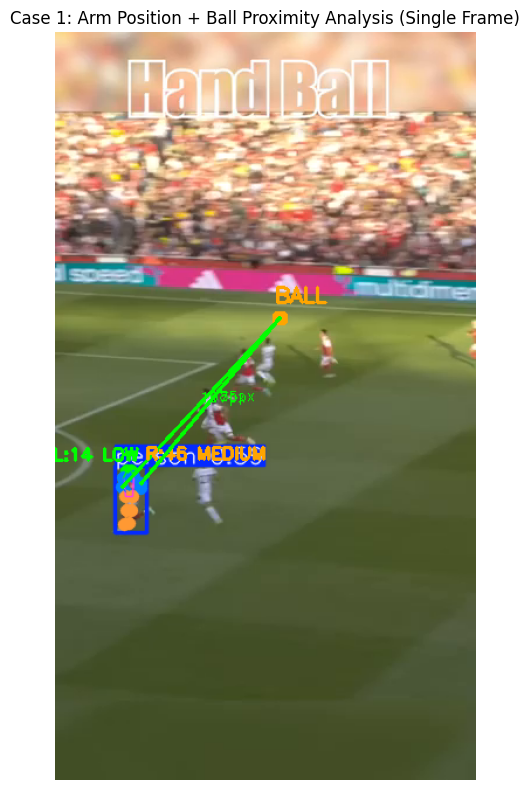

In [13]:
# Read a single frame from the video to test
cap = cv2.VideoCapture(VIDEO_PATH)
ret, test_frame = cap.read()
cap.release()

if not ret:
    print("Error: Could not read frame from video.")
else:
    # Run pose estimation on the test frame
    pose_results = pose_model(test_frame, verbose=False, conf=0.5)
    
    # Run ball detection on the test frame
    ball_results = ball_model(test_frame, verbose=False, conf=0.3, classes=BALL_CLASS_ID)
    
    # Get the annotated frame with skeletons drawn
    annotated = pose_results[0].plot()
    
    # --- Draw ball detections ---
    ball_centers = get_ball_centers(ball_results)
    for box in ball_results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 165, 255), 3)
        cv2.putText(annotated, "BALL", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 165, 255), 2)
    
    print(f"Detected {len(ball_centers)} ball(s) in the frame.\n")
    
    # --- Analyze each detected person ---
    if pose_results[0].keypoints is not None and len(pose_results[0].keypoints) > 0:
        keypoints = pose_results[0].keypoints.xy.cpu().numpy()
        print(f"Detected {len(keypoints)} person(s) in the frame.\n")
        
        for person_idx, kpts in enumerate(keypoints):
            print(f"--- Person {person_idx + 1} ---")
            
            # LEFT ARM: shoulder(5) → hip(11) vs shoulder(5) → elbow(7)
            l_shoulder = kpts[LEFT_SHOULDER]
            l_elbow    = kpts[LEFT_ELBOW]
            l_wrist    = kpts[LEFT_WRIST]
            l_hip      = kpts[LEFT_HIP]
            
            # RIGHT ARM: shoulder(6) → hip(12) vs shoulder(6) → elbow(8)
            r_shoulder = kpts[RIGHT_SHOULDER]
            r_elbow    = kpts[RIGHT_ELBOW]
            r_wrist    = kpts[RIGHT_WRIST]
            r_hip      = kpts[RIGHT_HIP]
            
            # ---- Left arm analysis ----
            if all(is_keypoint_valid(p) for p in [l_shoulder, l_elbow, l_hip]):
                left_angle = calculate_angle(l_shoulder, l_hip, l_elbow)
                left_risk = classify_risk(left_angle)
                color = get_risk_color(left_risk)
                
                # Ball distance to left arm
                left_arm_kps = [kp for kp in [l_elbow, l_wrist] if is_keypoint_valid(kp)]
                l_dist, l_arm_pt, l_ball_pt = min_distance_to_ball(left_arm_kps, ball_centers)
                
                # Decision
                l_decision, l_dec_color = make_handball_decision(left_risk, l_dist)
                
                dist_str = f"{l_dist:.0f}px" if l_dist is not None else "N/A"
                print(f"  Left arm angle:  {left_angle:.1f}° → Risk: {left_risk} | Ball dist: {dist_str} → {l_decision}")
                
                cv2.putText(annotated, f"L:{left_angle:.0f} {left_risk}",
                           (int(l_shoulder[0]) - 60, int(l_shoulder[1]) - 15),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                
                # Draw distance line if ball detected
                if l_arm_pt is not None and l_ball_pt is not None:
                    pt1 = (int(l_arm_pt[0]), int(l_arm_pt[1]))
                    pt2 = (int(l_ball_pt[0]), int(l_ball_pt[1]))
                    cv2.line(annotated, pt1, pt2, l_dec_color, 2)
                    mid = ((pt1[0]+pt2[0])//2, (pt1[1]+pt2[1])//2)
                    cv2.putText(annotated, f"{l_dist:.0f}px", mid, cv2.FONT_HERSHEY_SIMPLEX, 0.4, l_dec_color, 1)
            else:
                print("  Left arm: keypoints not detected")
            
            # ---- Right arm analysis ----
            if all(is_keypoint_valid(p) for p in [r_shoulder, r_elbow, r_hip]):
                right_angle = calculate_angle(r_shoulder, r_hip, r_elbow)
                right_risk = classify_risk(right_angle)
                color = get_risk_color(right_risk)
                
                # Ball distance to right arm
                right_arm_kps = [kp for kp in [r_elbow, r_wrist] if is_keypoint_valid(kp)]
                r_dist, r_arm_pt, r_ball_pt = min_distance_to_ball(right_arm_kps, ball_centers)
                
                # Decision
                r_decision, r_dec_color = make_handball_decision(right_risk, r_dist)
                
                dist_str = f"{r_dist:.0f}px" if r_dist is not None else "N/A"
                print(f"  Right arm angle: {right_angle:.1f}° → Risk: {right_risk} | Ball dist: {dist_str} → {r_decision}")
                
                cv2.putText(annotated, f"R:{right_angle:.0f} {right_risk}",
                           (int(r_shoulder[0]) + 10, int(r_shoulder[1]) - 15),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                
                # Draw distance line if ball detected
                if r_arm_pt is not None and r_ball_pt is not None:
                    pt1 = (int(r_arm_pt[0]), int(r_arm_pt[1]))
                    pt2 = (int(r_ball_pt[0]), int(r_ball_pt[1]))
                    cv2.line(annotated, pt1, pt2, r_dec_color, 2)
                    mid = ((pt1[0]+pt2[0])//2, (pt1[1]+pt2[1])//2)
                    cv2.putText(annotated, f"{r_dist:.0f}px", mid, cv2.FONT_HERSHEY_SIMPLEX, 0.4, r_dec_color, 1)
            else:
                print("  Right arm: keypoints not detected")
            print()
    else:
        print("No persons detected in the frame.")
    
    # Display the annotated frame
    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title("Case 1: Arm Position + Ball Proximity Analysis (Single Frame)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## Step 6 – Process the Full Video

Now we process the entire video frame-by-frame. For each frame, we:

1. **Run pose estimation** to detect all players and their keypoints.
2. **Run ball detection** to locate the football.
3. **Calculate the arm-torso angle** for both arms of each player and classify the risk.
4. **Calculate the distance** between the ball and each arm (elbow + wrist).
5. **Make a final decision** by combining both factors:
   - 🟢 **No Handball** — arm close to body OR ball far away
   - 🟠 **Possible Handball** — medium arm extension + ball close
   - 🔴 **Handball Detected** — arm unnaturally bigger + ball contact
6. **Annotate the frame** with angle labels, ball box, distance lines, and decision banners.
7. **Save the annotated video** to the output path.

In [23]:
def process_video_case1(video_path, output_path, pose_model, ball_model):
    """
    Process a football video to detect handball fouls based on Case 1:
    Arm making the body 'unnaturally bigger' (FIFA Law 12).
    
    Combines TWO factors:
      1. Arm-torso angle (is the arm extended unnaturally?)
      2. Ball proximity (is the ball close to the arm?)
    
    A handball is flagged only when BOTH conditions are met.
    
    Returns:
        dict with keys:
          - 'handball_frames': list of frame numbers where HANDBALL DETECTED
          - 'possible_frames': list of frame numbers where POSSIBLE HANDBALL
          - 'total_frames': total number of frames processed
    """
    
    # Open input video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return None
    
    # Get video properties
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Create output video writer
    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
    
    print(f"Processing video: {width}x{height} @ {fps}fps ({total_frames} frames)")
    print(f"Output: {output_path}")
    print(f"Angle thresholds: LOW < {ANGLE_LOW}° | MEDIUM {ANGLE_LOW}°-{ANGLE_HIGH}° | HIGH > {ANGLE_HIGH}°")
    print(f"Ball distance threshold: {BALL_DISTANCE_THRESHOLD}px")
    print("-" * 60)
    
    frame_count = 0
    handball_detected_frames = []   # Frame numbers with HANDBALL DETECTED
    possible_handball_frames = []   # Frame numbers with POSSIBLE HANDBALL
    
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break
        
        frame_count += 1
        if frame_count % 30 == 0:
            print(f"Processing frame {frame_count}/{total_frames}...")
        
        # ---- Run both AI models ----
        pose_results = pose_model(frame, verbose=False, conf=0.5)
        ball_results = ball_model(frame, verbose=False, conf=0.3, classes=BALL_CLASS_ID)
        
        # Start with the pose-annotated frame (shows skeletons)
        annotated_frame = pose_results[0].plot()
        
        # ---- Draw ball detections ----
        ball_centers = get_ball_centers(ball_results)
        for box in ball_results[0].boxes:
            bx1, by1, bx2, by2 = map(int, box.xyxy[0])
            cv2.rectangle(annotated_frame, (bx1, by1), (bx2, by2), (0, 165, 255), 3)
            cv2.putText(annotated_frame, "BALL", (bx1, by1 - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 165, 255), 2)
        
        frame_decision = "NO HANDBALL"
        frame_decision_color = (0, 255, 0)
        
        # ---- Analyze each detected person ----
        if pose_results[0].keypoints is not None and len(pose_results[0].keypoints) > 0:
            keypoints = pose_results[0].keypoints.xy.cpu().numpy()
            
            for person_idx, kpts in enumerate(keypoints):
                
                # -- LEFT ARM analysis --
                l_shoulder = kpts[LEFT_SHOULDER]
                l_elbow    = kpts[LEFT_ELBOW]
                l_wrist    = kpts[LEFT_WRIST]
                l_hip      = kpts[LEFT_HIP]
                
                if all(is_keypoint_valid(p) for p in [l_shoulder, l_elbow, l_hip]):
                    left_angle = calculate_angle(l_shoulder, l_hip, l_elbow)
                    left_risk  = classify_risk(left_angle)
                    color      = get_risk_color(left_risk)
                    
                    if left_angle is not None:
                        # Draw angle label
                        label_pos = (int(l_shoulder[0]) - 70, int(l_shoulder[1]) - 15)
                        cv2.putText(annotated_frame, f"L:{left_angle:.0f} {left_risk}",
                                   label_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                        
                        # Ball proximity check for left arm
                        left_arm_kps = [kp for kp in [l_elbow, l_wrist] if is_keypoint_valid(kp)]
                        l_dist, l_arm_pt, l_ball_pt = min_distance_to_ball(left_arm_kps, ball_centers)
                        l_decision, l_dec_color = make_handball_decision(left_risk, l_dist)
                        
                        # Draw distance line
                        if l_arm_pt is not None and l_ball_pt is not None:
                            pt1 = (int(l_arm_pt[0]), int(l_arm_pt[1]))
                            pt2 = (int(l_ball_pt[0]), int(l_ball_pt[1]))
                            cv2.line(annotated_frame, pt1, pt2, l_dec_color, 2)
                            mid = ((pt1[0]+pt2[0])//2, (pt1[1]+pt2[1])//2)
                            cv2.putText(annotated_frame, f"{l_dist:.0f}px", mid,
                                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, l_dec_color, 1)
                        
                        # Highlight elbow for high risk
                        if left_risk == "HIGH":
                            cv2.circle(annotated_frame, (int(l_elbow[0]), int(l_elbow[1])), 10, color, -1)
                        
                        # Update frame-level decision (escalate only)
                        if l_decision == "HANDBALL DETECTED":
                            frame_decision = "HANDBALL DETECTED"
                            frame_decision_color = (0, 0, 255)
                        elif l_decision == "POSSIBLE HANDBALL" and frame_decision != "HANDBALL DETECTED":
                            frame_decision = "POSSIBLE HANDBALL"
                            frame_decision_color = (0, 165, 255)
                
                # -- RIGHT ARM analysis --
                r_shoulder = kpts[RIGHT_SHOULDER]
                r_elbow    = kpts[RIGHT_ELBOW]
                r_wrist    = kpts[RIGHT_WRIST]
                r_hip      = kpts[RIGHT_HIP]
                
                if all(is_keypoint_valid(p) for p in [r_shoulder, r_elbow, r_hip]):
                    right_angle = calculate_angle(r_shoulder, r_hip, r_elbow)
                    right_risk  = classify_risk(right_angle)
                    color       = get_risk_color(right_risk)
                    
                    if right_angle is not None:
                        # Draw angle label
                        label_pos = (int(r_shoulder[0]) + 10, int(r_shoulder[1]) - 15)
                        cv2.putText(annotated_frame, f"R:{right_angle:.0f} {right_risk}",
                                   label_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                        
                        # Ball proximity check for right arm
                        right_arm_kps = [kp for kp in [r_elbow, r_wrist] if is_keypoint_valid(kp)]
                        r_dist, r_arm_pt, r_ball_pt = min_distance_to_ball(right_arm_kps, ball_centers)
                        r_decision, r_dec_color = make_handball_decision(right_risk, r_dist)
                        
                        # Draw distance line
                        if r_arm_pt is not None and r_ball_pt is not None:
                            pt1 = (int(r_arm_pt[0]), int(r_arm_pt[1]))
                            pt2 = (int(r_ball_pt[0]), int(r_ball_pt[1]))
                            cv2.line(annotated_frame, pt1, pt2, r_dec_color, 2)
                            mid = ((pt1[0]+pt2[0])//2, (pt1[1]+pt2[1])//2)
                            cv2.putText(annotated_frame, f"{r_dist:.0f}px", mid,
                                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, r_dec_color, 1)
                        
                        # Highlight elbow for high risk
                        if right_risk == "HIGH":
                            cv2.circle(annotated_frame, (int(r_elbow[0]), int(r_elbow[1])), 10, color, -1)
                        
                        # Update frame-level decision (escalate only)
                        if r_decision == "HANDBALL DETECTED":
                            frame_decision = "HANDBALL DETECTED"
                            frame_decision_color = (0, 0, 255)
                        elif r_decision == "POSSIBLE HANDBALL" and frame_decision != "HANDBALL DETECTED":
                            frame_decision = "POSSIBLE HANDBALL"
                            frame_decision_color = (0, 165, 255)
        
        # ---- Draw the frame-level decision banner ----
        if frame_decision == "HANDBALL DETECTED":
            handball_detected_frames.append(frame_count)
            cv2.putText(annotated_frame, "HANDBALL DETECTED", (20, 40),
                       cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)
            cv2.putText(annotated_frame, "Arm unnaturally bigger + Ball contact", (20, 70),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
        elif frame_decision == "POSSIBLE HANDBALL":
            possible_handball_frames.append(frame_count)
            cv2.putText(annotated_frame, "POSSIBLE HANDBALL", (20, 40),
                       cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 165, 255), 3)
            cv2.putText(annotated_frame, "Medium arm extension + Ball close", (20, 70),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 165, 255), 2)
        
        # Write the annotated frame to output
        out.write(annotated_frame)
    
    # Cleanup
    cap.release()
    out.release()
    
    # Build results dictionary
    results = {
        'handball_frames': handball_detected_frames,
        'possible_frames': possible_handball_frames,
        'total_frames': frame_count,
        'fps': fps,
    }
    
    print("-" * 60)
    print(f"Done! Processed {frame_count} frames.")
    print(f"HANDBALL DETECTED frames:  {len(handball_detected_frames)}/{frame_count} ({100*len(handball_detected_frames)/max(frame_count,1):.1f}%)")
    print(f"POSSIBLE HANDBALL frames:  {len(possible_handball_frames)}/{frame_count} ({100*len(possible_handball_frames)/max(frame_count,1):.1f}%)")
    clean = frame_count - len(handball_detected_frames) - len(possible_handball_frames)
    print(f"Clean frames:              {clean}/{frame_count}")
    print(f"\nOutput saved to: {output_path}")
    
    if handball_detected_frames:
        print(f"\n⚠️  FINAL VERDICT: HANDBALL FOUL DETECTED in {len(handball_detected_frames)} frame(s)!")
        print(f"    Frames: {handball_detected_frames}")
    elif possible_handball_frames:
        print(f"\n⚠️  FINAL VERDICT: POSSIBLE HANDBALL in {len(possible_handball_frames)} frame(s) — needs referee review.")
        print(f"    Frames: {possible_handball_frames}")
    else:
        print(f"\n✅ FINAL VERDICT: NO HANDBALL detected in this video.")
    
    return results


print("Video processing function defined.")

Video processing function defined.


## Step 7 – Run the Video Processing

Execute the full video processing pipeline. This will read each frame from the input video, analyze all detected players' arm positions, and write the annotated output.

In [24]:
# Run the full video processing pipeline (with both pose + ball models)
# The returned 'results' dict contains the detected frame numbers for later use
results = process_video_case1(VIDEO_PATH, OUTPUT_PATH, pose_model, ball_model)

Processing video: 360x640 @ 29fps (253 frames)
Output: ../output/case1_arm_unnaturally_bigger.mp4
Angle thresholds: LOW < 30° | MEDIUM 30°-70° | HIGH > 70°
Ball distance threshold: 150px
------------------------------------------------------------


Processing frame 30/253...
Processing frame 60/253...
Processing frame 90/253...
Processing frame 120/253...
Processing frame 150/253...
Processing frame 180/253...
Processing frame 210/253...
Processing frame 240/253...
------------------------------------------------------------
Done! Processed 253 frames.
HANDBALL DETECTED frames:  10/253 (4.0%)
POSSIBLE HANDBALL frames:  72/253 (28.5%)
Clean frames:              171/253

Output saved to: ../output/case1_arm_unnaturally_bigger.mp4

⚠️  FINAL VERDICT: HANDBALL FOUL DETECTED in 10 frame(s)!
    Frames: [90, 91, 92, 93, 94, 199, 200, 201, 204, 205]


## Step 8 – Preview Output Frames

Let's preview a few frames from the output video to verify the annotations. We sample frames evenly throughout the video. Look for:
- **Orange boxes** around the ball.
- **Color-coded angle labels** (L: / R:) near each shoulder.
- **Distance lines** between the ball and the nearest arm keypoint.
- **Decision banners** at the top of the frame (red = handball, orange = possible, none = clean).

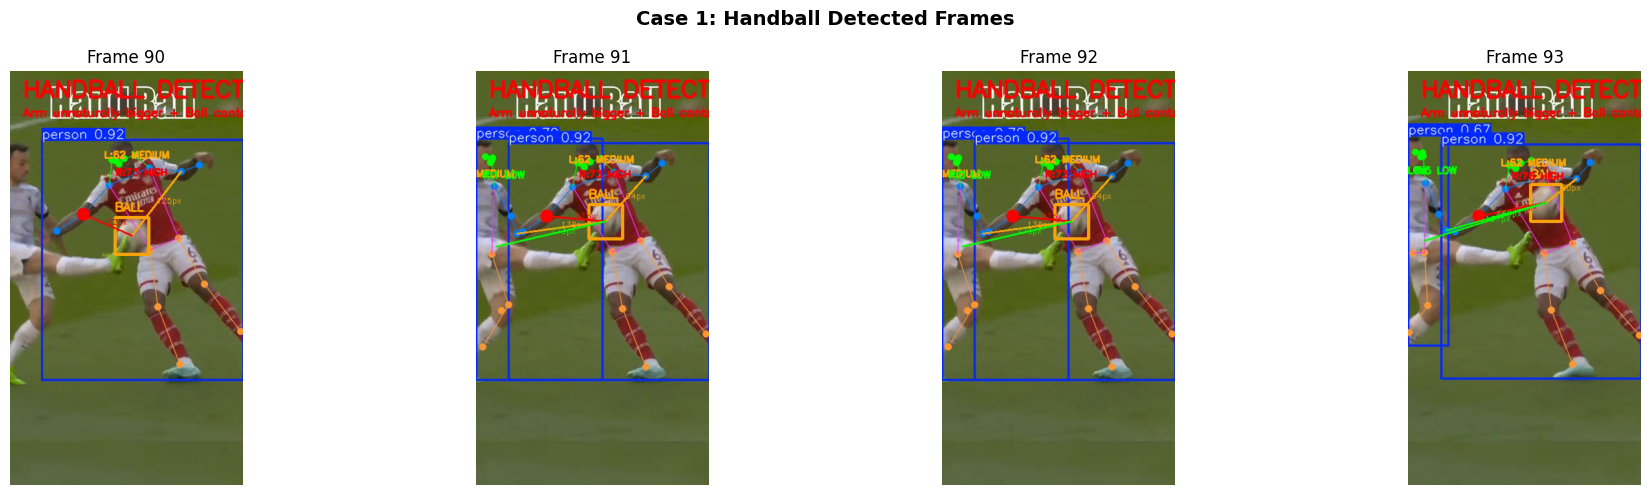

In [25]:
# Preview frames from the annotated output video
# Prioritize: handball frames > possible handball frames > evenly sampled
cap = cv2.VideoCapture(OUTPUT_PATH)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if results and results['handball_frames']:
    sample_indices = results['handball_frames'][:4]
    title = "Case 1: Handball Detected Frames"
elif results and results['possible_frames']:
    sample_indices = results['possible_frames'][:4]
    title = "Case 1: Possible Handball Frames"
else:
    sample_indices = [int(total * i / 4) for i in range(4)]
    title = "Case 1: Sample Frames (No Handball Detected)"

n = min(len(sample_indices), 4)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for i, frame_idx in enumerate(sample_indices[:n]):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx - 1)  # frame_idx is 1-based
    ret, frame = cap.read()
    if ret:
        axes[i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Frame {frame_idx}")
        axes[i].axis('off')

cap.release()
plt.suptitle(title, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

### What This Notebook Does
This notebook implements **Case 1** of handball foul detection: detecting when a player's arm makes the body **"unnaturally bigger"** while the ball is in contact with the arm (FIFA Law 12).

### How It Works — Two-Factor Decision
1. **Pose Estimation** (YOLOv8-pose): Detects 17 body keypoints per player. We compute the angle between the **upper arm** (shoulder → elbow) and the **torso** (shoulder → hip).
2. **Ball Detection** (YOLOv8x): Locates the football in each frame. We calculate the **Euclidean distance** between the ball center and the nearest arm keypoint (elbow/wrist).
3. **Combined Decision**:

| Arm Angle Risk | Ball Proximity | Decision |
|---------------|---------------|----------|
| LOW (< 30°) | Any | **No Handball** |
| MEDIUM (30°–70°) | Ball far | **No Handball** |
| MEDIUM (30°–70°) | Ball close (< 150px) | **Possible Handball** |
| HIGH (> 70°) | Ball far | **No Handball** |
| HIGH (> 70°) | Ball close (< 150px) | **Handball Detected** |

### Visual Output
- **Green** labels/lines = No handball risk.
- **Orange** labels/lines = Possible handball (needs review).
- **Red** labels/lines/banner = Handball detected.
- Ball drawn with an **orange bounding box**.
- **Distance lines** from ball to nearest arm keypoint with pixel distance displayed.

### Limitations
- The model only sees 2D projections — camera angle affects the measured angles and distances.
- It does not account for the player's movement context (running, jumping, sliding).
- Thresholds (30°/70° angles, 150px distance) can be tuned depending on desired sensitivity and video resolution.
- Ball detection confidence is lower on small/distant balls.

### How This Helps a Referee
Instead of relying on subjective opinion, this system provides:
1. A **numerical arm angle measurement** (how far is the arm from the body?)
2. A **numerical ball distance measurement** (how close is the ball to the arm?)
3. A **combined verdict** that flags only frames where both conditions are met.

This gives VAR operators two objective data points to support their handball decision.